In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


- Camada de entrada, recebendo imagem em pixels, 

- camada oculta, imagem compactada

- camada de saída, decodificação, para voltar a imagem ao estado original

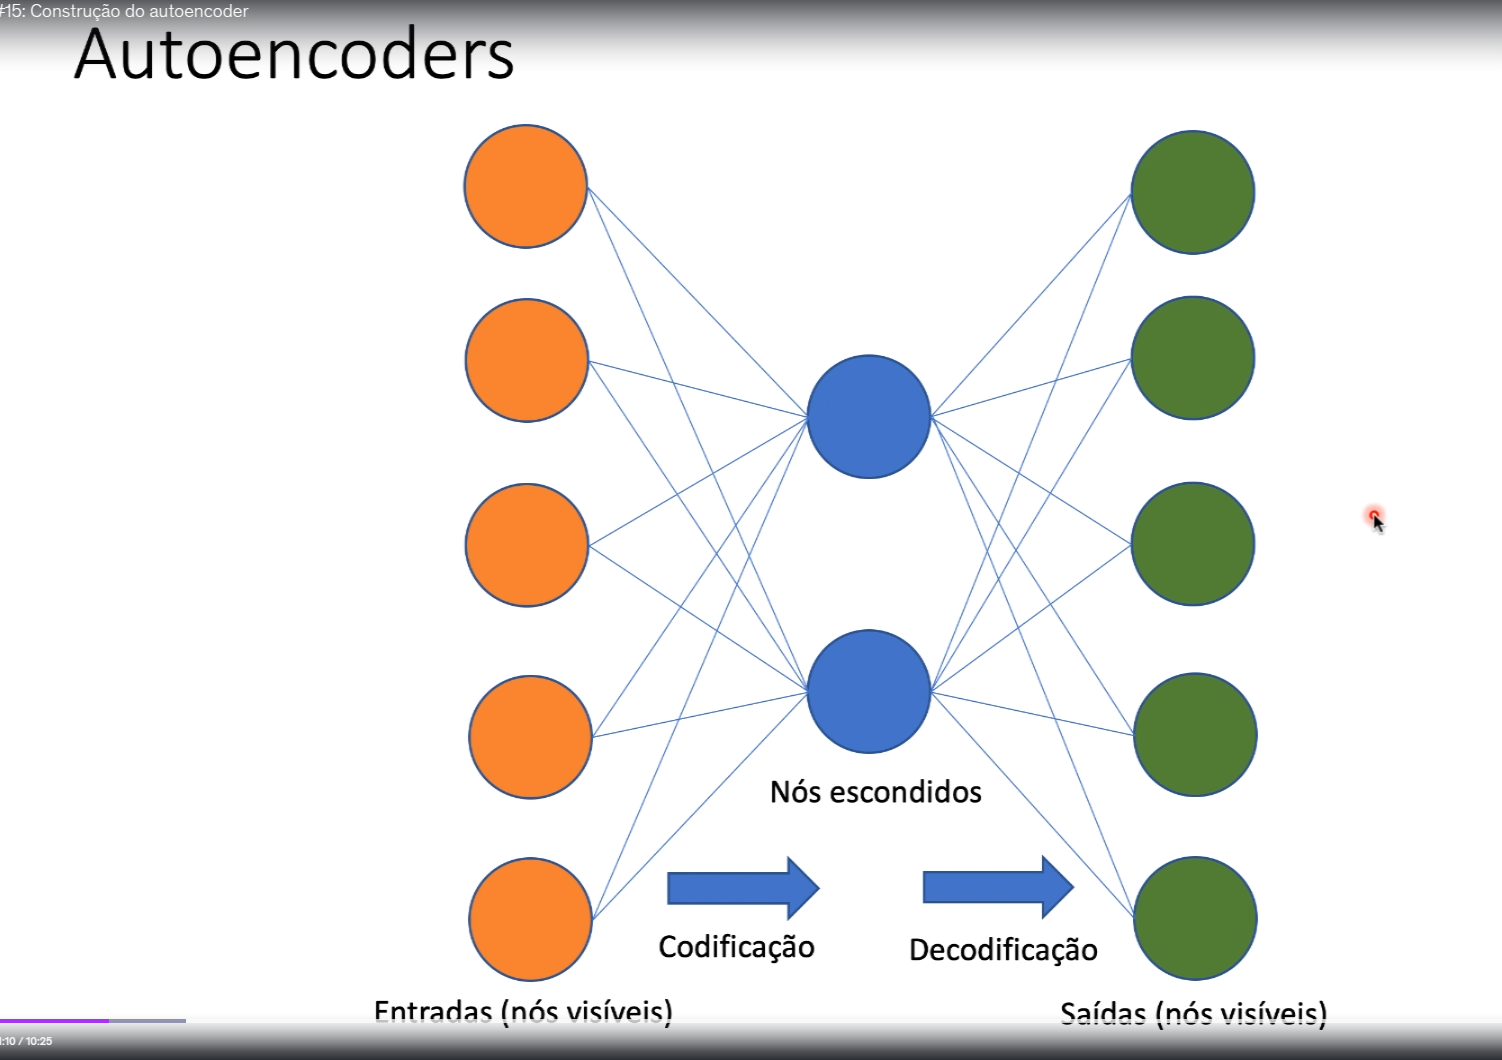

# Projeto 15: Compactação de imagens com autoencoders

## Etapa 1: Importação das bibliotecas

In [2]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
torch.__version__

'2.9.1+cpu'

In [3]:
torch.manual_seed(123) #semente aleatória randomica

## Etapa 2: Base de dados

In [4]:
# coleta os dados do pytorch
# loader para intera, dentro do dataloader, treinamento de 256 a 256 registros, 
#  shuffle = True para embaralhar os dados. 

dataset_train = datasets.MNIST('MNIST-data', train = True, download = True,
                               transform = transforms.ToTensor())
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 256,
                                           shuffle = True)

In [5]:
# criou a pasta MNIST-data
# criando os dados de teste, ou de validação, train = False. 
dataset_val = datasets.MNIST('MNIST-data', train = False, download = True,
                             transform = transforms.ToTensor())
loader_val = torch.utils.data.DataLoader(dataset_val, batch_size = 256,
                                         shuffle = True)

## Etapa 3: Construção do autoencoder

In [6]:
# Recebe 784 entradas (ex: uma imagem 28x28 achatada).
# neuônios de entradas
print(28*28)

784


In [7]:
# Definindo a classe do Autoencoder que herda de nn.Module (base do PyTorch)
# 784 -> 32 -> 784
class autoencoder(nn.Module):
   # inicializar o objeto
  def __init__(self):
    # construção a super classe, modulo
    super().__init__()
    # definição dos objetos  
    # ENCODER (Codificador):
    # Recebe 784 entradas (ex: uma imagem 28x28 achatada).
    # Reduz para 32 neurônios. Isso cria um 'gargalo' que força a rede 
    # a aprender apenas o que é mais importante na imagem.
    # in_features neurônios de entradas, como temos as imagens 28x28  
    # receber 784 neurônios, e vamos colocar 32 neurônios na camada oculta ou escondida
    self.dense0 = nn.Linear(in_features=784, out_features=32)
    self.activation0 = nn.ReLU() #indo para a camada oculta
    # nn.ReLU(): É a função de ativação mais usada em redes neurais profundas.
    # O que ela faz matematicamente: f(x) = max(0, x)
    # 1. Se o valor vindo do neurônio for POSITIVO, ela deixa passar exatamente como está.
    # 2. Se o valor for NEGATIVO, ela transforma em ZERO (bloqueia o neurônio).    
    # Por que ela é essencial?
    # - Sem ela, sua rede seria apenas uma sucessão de somas lineares (como uma reta).
    # - Com a ReLU, a rede consegue aprender padrões não lineares e complexos 
    #   (curvas, formas e características sofisticadas).
    # ***********************************************************************
      
    # DECODER (Decodificador), processo inverso:
    # Pega os 32 dados comprimidos e tenta reconstruir os 784 originais.
    self.dense1 = nn.Linear(32, 784) # agora estamos na camada oculta e indo para a camada de saída
    # Sigmoid: Garante que os pixels reconstruídos estejam entre 0 e 1.
    self.activation1 = nn.Sigmoid()
    # nn.Sigmoid(): Função de ativação que transforma valores reais em um intervalo entre 0 e 1.
    # Curva em formato de 'S': Valores muito altos viram 1, valores muito baixos viram 0.    
    # Por que ela está no final do seu Autoencoder?
    # 1. Normalização de Pixels: Como imagens digitais costumam ter pixels normalizados 
    #    entre 0 e 1, a Sigmoid garante que a imagem reconstruída pela rede respeite esse limite.
    # 2. Reconstrução: Ela ajuda a rede a decidir se um pixel deve estar "aceso" (próximo de 1) 
    #    ou "apagado" (próximo de 0).
    # ***********************************************************************

  # O método forward define o caminho que o dado percorre
  def forward(self, X):
    # 784 neurônios na entrada -> 32 -> 784  
    # 28*28 = 784, cada pixels entrada na camada de entrada  
    # Garante que a imagem seja um vetor de 784 colunas, independente do batch
    # comando view é para fazer a conversão da imagem, tamanho do bacth para facilitar a alteração 1,   
    X = X.view(-1, 28*28) # formato de vetor agora a imagem.
    
    # Passo 1: Comprime (Encoder)
    X = self.dense0(X)
    X = self.activation0(X)
    
    # Passo 2: Reconstrói (Decoder)
    X = self.dense1(X)
    X = self.activation1(X)
    
    # Retorna a imagem 'reconstruída' pela rede
    return X

- ReLU (no meio)

Filtrar ruído e dar poder de aprendizado.

$0$ até o Infinito

É rápida e evita que a rede pare de aprender.


- Sigmoid (no final)

Finalizar o dado em um formato específico

Exatamente entre $0$ e $1$.

Perfeita para representar probabilidades ou intensidades de pixels.


In [8]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device # cuidado, no google colab as vezes tem limite para usar o cuda

device(type='cpu')

In [9]:
# mandar os dados para a cpu

# 1. Instanciação: Aqui cria o objeto 'model' baseado na classe autoencoder que definiu.
# É como se a classe fosse a planta da casa e o 'model' fosse a casa construída.
model = autoencoder()

# 2. Migração de Hardware (to device):
# Envia todos os pesos e cálculos da rede para o processador escolhido (CPU ou GPU/CUDA).
# Se o seu 'device' for 'cuda', a rede será processada pela placa de vídeo, 
# o que pode ser até 50x mais rápido do que na CPU.
model.to(device)


autoencoder(
  (dense0): Linear(in_features=784, out_features=32, bias=True)
  (activation0): ReLU()
  (dense1): Linear(in_features=32, out_features=784, bias=True)
  (activation1): Sigmoid()
)

In [10]:
# 1. CRITERION (O Juiz/Função de Perda):
# nn.BCELoss (Binary Cross Entropy): Mede a distância entre a imagem original e a reconstrução.
# Como você usou Sigmoid na última camada (valores entre 0 e 1), o BCELoss trata 
# cada pixel como uma probabilidade e calcula o erro. 
# Quanto mais "embaçada" a reconstrução, maior será o valor desta perda.
criterion = nn.BCELoss()

# 2. OPTIMIZER (O Treinador):
# optim.Adam: É um dos algoritmos de otimização mais inteligentes. 
# Ele ajusta os pesos da rede de forma automática e eficiente.
# model.parameters(): Indica ao Adam que ele deve "girar os parafusos" (ajustar os pesos)
# de todas as camadas que você definiu na classe autoencoder.
optimizer = optim.Adam(model.parameters())

## Etapa 4: Treinamento do modelo

In [11]:
# Inicia o loop de épocas (20 passagens completas pelos dados)
for epoch in range(20):
    
    # --- FASE DE TREINAMENTO PRIMEIRA PARTE---
    running_loss_train = 0.
    # E percorrer o loader, separados com os batch_size, com 256 registros #
    for data in loader_train: # base de dados de treino
      model.train()              # Ativa o modo de treino (habilita Dropout, Batch Normalization, etc.)
      # fazer o treino e depois a validação
      # inputs são as entradas das figuras em pixels, e o _ será reconstruindo na saída a própria imagem. 
      inputs, _ = data           # Pega as imagens. O '_' ignora as etiquetas (labels), pois autoencoders usam a própria imagem como alvo.
      # no fim vamos carregar apenas a entrada das imagens, inputs.   
      inputs = inputs.to(device) # Envia as imagens para a GPU/CPU
      
      optimizer.zero_grad()      # Zera os gradientes acumulados da rodada anterior (limpa a memória do erro)
        
      # passando os dados para a rede neural, usando  o forward e passando os dados para a camada oculta. 
      # autoencoder, compara a entrada com a saída construída.   
      outputs = model.forward(inputs) # Forward: A rede tenta reconstruir a imagem
      
      # Compara a reconstrução (outputs) com a imagem original (inputs)
      loss = criterion(outputs, inputs.view(*outputs.shape)) # .shape para colocar no mesmo formato o input como outputs
      # 784 imagens em formato de vetor.  
      
      loss.backward()            # Backpropagation: Calcula o quanto cada neurônio errou
      optimizer.step()           # Atualiza os pesos: O "treinador" ajusta a rede para errar menos na próxima
      
      running_loss_train += loss.item() # Acumula o erro para calcular a média depois

    # --- FASE DE VALIDAÇÃO / PARTE 2 validação---
    running_loss_val = 0.
    for data in loader_val: # LOADER DE VALIDAÇÃO, base de dados de teste
      model.eval()               # Ativa modo de avaliação (desativa cálculos desnecessários como Dropout)
      inputs, _ = data
      inputs = inputs.to(device)
      #  não usamos o Zera os gradientes acumulados, pois não estamos treinando
      # não usamos a atualização dos pesos, não usamos o (loss.backward()) e nem o (optimizer.step())
        
      # No forward da validação, não calculamos gradientes nem atualizamos pesos!
      outputs = model.forward(inputs)
      loss = criterion(outputs, inputs.view(*outputs.shape))
      
      running_loss_val += loss.item()

    # --- FINAL DA ÉPOCA ---
    # Exibe o progresso: Perda de treino vs Perda de validação
    # O ideal é que ambas diminuam juntas.
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(
        epoch + 1, 
        running_loss_train/len(loader_train), 
        running_loss_val/len(loader_val)
    ))

ÉPOCA   1: perda_train 0.29529 perda_val 0.19752
ÉPOCA   2: perda_train 0.18119 perda_val 0.16547
ÉPOCA   3: perda_train 0.15759 perda_val 0.14778
ÉPOCA   4: perda_train 0.14333 perda_val 0.13660
ÉPOCA   5: perda_train 0.13427 perda_val 0.12921
ÉPOCA   6: perda_train 0.12780 perda_val 0.12397
ÉPOCA   7: perda_train 0.12312 perda_val 0.11901
ÉPOCA   8: perda_train 0.11805 perda_val 0.11451
ÉPOCA   9: perda_train 0.11506 perda_val 0.11267
ÉPOCA  10: perda_train 0.11310 perda_val 0.11086
ÉPOCA  11: perda_train 0.11184 perda_val 0.10954
ÉPOCA  12: perda_train 0.11099 perda_val 0.10927
ÉPOCA  13: perda_train 0.11038 perda_val 0.10839
ÉPOCA  14: perda_train 0.11003 perda_val 0.10836
ÉPOCA  15: perda_train 0.10971 perda_val 0.10761
ÉPOCA  16: perda_train 0.10814 perda_val 0.10623
ÉPOCA  17: perda_train 0.10751 perda_val 0.10551
ÉPOCA  18: perda_train 0.10714 perda_val 0.10535
ÉPOCA  19: perda_train 0.10689 perda_val 0.10544
ÉPOCA  20: perda_train 0.10675 perda_val 0.10555


In [12]:
# perda_val, perda de validação

## Etapa 5: Geração do encoder

In [13]:
# lista com todas as camadas

# model.children(): Retorna um gerador (lista) com as camadas de alto nível do modelo.
# Por exemplo, no seu Autoencoder, ele retornaria:
# [Linear(784->32), ReLU(), Linear(32->784), Sigmoid()]

# Um uso muito comum é para ver a estrutura ou extrair partes do modelo:
for camada in model.children():
    print(camada)

# Outro uso é para transformar o modelo em uma lista de camadas:
camadas = list(model.children())
primeira_camada = camadas[0]

Linear(in_features=784, out_features=32, bias=True)
ReLU()
Linear(in_features=32, out_features=784, bias=True)
Sigmoid()


In [14]:
primeira_camada

Linear(in_features=784, out_features=32, bias=True)

In [15]:
list(model.children())

[Linear(in_features=784, out_features=32, bias=True),
 ReLU(),
 Linear(in_features=32, out_features=784, bias=True),
 Sigmoid()]

verificar quais são as camadas do codificador e do decodificador, pois quando vamos fazer o teste na sequência, precisamos passar uma imagem para o codificador e ele vai ter que colocar em 32 pixels, de 784 pixels para 32 (primeiro codificador). 

depois tem que entrar com 32 e sair com 784 (segundo decodificador)

In [16]:
# classe para pegar essa respectiva camada
list(model.children())[1]

ReLU()

In [17]:
list(model.children())[0]

Linear(in_features=784, out_features=32, bias=True)

In [18]:
# Definindo a classe Encoder (a parte que comprime os dados)
class encoder(nn.Module):
  def __init__(self):
    super().__init__()
    # decomposição do Codificador
    # list(model.children()): Pega as camadas do Autoencoder que já treinamos.
    # [0]: Pega a primeira camada (a Linear de 784 -> 32).
    # [1]: Pega a segunda camada (a ativação ReLU).
    # Isso garante que o Encoder use o conhecimento que a rede adquiriu no treino.
    self.dense0 = list(model.children())[0]
    self.activation0 = list(model.children())[1]

  def forward(self, X):
    # converter para o formato de vetor  
    # Achata a imagem de 28x28 para um vetor de 784 posições
    X = X.view(-1, 28*28)
    
    # Passa o dado pela camada de compressão e pela ativação
    X = self.dense0(X) # ligação da camada de entrada
    X = self.activation0(X) # ligados os 784 neurônios para a função de ativação
    
    # O resultado aqui não é uma imagem, mas sim a "essência" dela (32 números)
    return X

In [19]:
# mandar o processo para a cpu
# 1. Instanciação: Cria o objeto 'model1' a partir da classe encoder.
# Como vimos antes, este objeto agora contém apenas a parte da rede 
# que transforma 784 pixels em 32 números (os pesos já treinados).
model1 = encoder()

# 2. Migração para o Hardware:
# Move o modelo para a GPU (se disponível) ou CPU. 
# Isso é essencial para que possamos passar imagens pelo encoder 
# e obter a compressão de forma rápida, usando o mesmo hardware onde os dados estão.
model1.to(device)

encoder(
  (dense0): Linear(in_features=784, out_features=32, bias=True)
  (activation0): ReLU()
)

## Etapa 6: Geração do decoder

In [20]:
# para decodificar

In [21]:
list(model.children())[3]

Sigmoid()

In [22]:
list(model.children())[2]

Linear(in_features=32, out_features=784, bias=True)

In [23]:
# Definindo a classe Decoder (a parte que reconstrói a imagem)
class decoder(nn.Module):
  def __init__(self):
    super().__init__() # construção da super classe
    
    # list(model.children()): Acessa as camadas do Autoencoder original.
    # [2]: Pega a terceira camada (a Linear de 32 -> 784).
    # [3]: Pega a quarta camada (a ativação Sigmoid).
    # Assim como no encoder, aqui você aproveita os pesos que a rede já aprendeu.
    self.dense0 = list(model.children())[2] # primeira camada 32 pixels imagem, e retorna a imagem com 784 pixels
    self.activation0 = list(model.children())[3]

  def forward(self, X):
    # Recebe os 32 números (vetor latente)
    X = self.dense0(X)       # Expande de 32 para 784 neurônios # recebe as imagens codificadas
    X = self.activation0(X)  # Aplica Sigmoid para os valores ficarem entre 0 e 1 (pixels), pela função de ativação
    
    # O resultado é um vetor de 784 que pode ser remodelado (28x28) para virar imagem
    return X

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

# 🔹 O ReLU (Rectified Linear Unit)

Características:

Simples, rápido de calcular.

Resolve o problema do vanishing gradient (quando os gradientes ficam quase zero em sigmoides/tanh).

Muito usado em camadas ocultas.

⚠️ Problema: pode causar “neurônios mortos” (quando muitos valores ficam ≤ 0 e nunca mais reativam).


# 🔹 1. Sigmoid

Saída entre 0 e 1 → ideal para classificação binária.

Problema: saturação → gradientes muito pequenos para valores extremos.

# 🔹 2. Tanh (Tangente Hiperbólica)

Saída entre -1 e 1.

Centraliza os dados em torno de 0 (melhor que sigmoid).

Mas ainda sofre com vanishing gradient.

# 🔹 3. Leaky ReLU

Variante do ReLU que deixa um “vazamento” para valores negativos.

Resolve o problema de neurônios mortos.

#🔹 4. ELU (Exponential Linear Unit)

Parecido com ReLU, mas valores negativos seguem uma curva exponencial suave.
Melhora a aprendizagem, mas é mais caro computacionalmente.

#🔹 5. Softmax

Transforma um vetor de valores em probabilidades que somam 1.

Usado em classificação multiclasse (saída com várias categorias).



🔹 Resumo, o uso mais comum:

Camadas ocultas → ReLU, Leaky ReLU, às vezes Tanh/ELU.

Saída binária → Sigmoid.

Saída multiclasse → Softmax.



### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

### valores numéricos de séries temporais (ex: vendas, demanda, preços), o ideal é:

- ReLU nas camadas ocultas

- Linear (sem ativação) na saída.

In [24]:
#mandamos para a cpu

In [25]:
# 1. Instanciação: Cria o objeto 'model2' usando a classe decoder.
# Este modelo "herda" as camadas finais (2 e 3) do seu autoencoder treinado.
# Ele agora é um especialista em transformar 32 números na imagem original de 784 pixels.
model2 = decoder()

# 2. Migração para o Hardware:
# Envia o reconstrutor para a GPU (cuda) ou CPU.
# Isso é crucial porque, se você comprimiu a imagem na GPU (model1), 
# Precisamos estar na mesma GPU para reconstruí-la (model2).
model2.to(device)

decoder(
  (dense0): Linear(in_features=32, out_features=784, bias=True)
  (activation0): Sigmoid()
)

In [26]:
# loader_val, com shuffle True, modo aleatório;

## Etapa 7: Visualização dos resultados

In [27]:
loader_val

In [28]:
# numero_imagens = 10: Define que vamos pegar apenas 10 fotos para o teste visual.

# next(iter(loader_val)): 
# 1. iter() transforma o carregador de dados em um "iterador".
# 2. next() pega o primeiro "pacote" (batch) de imagens desse iterador.
# [0]: O loader retorna (imagem, etiqueta). O [0] garante que pegamos apenas as imagens.
# [:numero_imagens]: Corta o pacote para ficarmos apenas com as primeiras 10 imagens.
numero_imagens = 10
imagens_teste = next(iter(loader_val))[0][:numero_imagens] 
# mostrar uma tupla pelo loader_val, coloa [0] para coletar a imagem

# imagens_teste.to(device):
# Envia essas 10 imagens para a GPU (ou CPU), o mesmo local onde o nosso 
# model1 (Encoder) e model2 (Decoder) estão morando. 
# Se você não fizer isso, o modelo não conseguirá processar as imagens.

imagens_teste = imagens_teste.to(device)

In [29]:
imagens_teste.shape

torch.Size([10, 1, 28, 28])

In [32]:
# transforma matriz em um vetor
# 10 número das imagens
# 1 canal imagem, na escala de uma cor, cinza
# 28 x28 dimensões

In [30]:
# Imagens codificadas
# --- Imagens codificadas ---

# model1.eval(): 
# Coloca o Encoder em modo de avaliação. Isso é importante porque avisa ao PyTorch 
# que não estamos mais treinando, então ele pode desativar comportamentos como 
# Dropout e economizar memória/processamento.
model1.eval()

# imagens_codificadas = model1(imagens_teste):
# Aqui ocorre a "mágica" da compressão. 
# Você passa as 10 imagens originais (que tinham 784 pixels cada) pelo modelo.
# O resultado (imagens_codificadas) será uma matriz com apenas 32 números para cada imagem.
imagens_codificadas = model1(imagens_teste)

In [31]:
# imagens codificadas
# saída de 32 pixels com 10 imagens
imagens_codificadas.shape

torch.Size([10, 32])

### vamos decodificar o modelo agora 

In [33]:
# Imagens decodificadas
# --- Imagens decodificadas ---

# model2.eval():
# Assim como no encoder, colocamos o Decoder em modo de avaliação.
# Isso garante que ele use os pesos fixos que aprendeu no treino para 
# reconstruir a imagem da forma mais precisa possível.
model2.eval()

# imagens_decodificadas = model2(imagens_codificadas):
# O Decoder recebe os vetores de 32 números (espaço latente).
# Ele processa esses números através da camada Linear(32, 784) e da Sigmoid.
# O resultado final é um conjunto de 10 imagens reconstruídas.
imagens_decodificadas = model2(imagens_codificadas)

In [34]:
#retorna 10 imagens, com um valor origina de 784 pixels
imagens_decodificadas.shape

torch.Size([10, 784])

In [36]:
# 1. Preparando as imagens originais para visualização
# .reshape(-1, 28, 28): Pega o vetor de 784 e transforma de volta em um quadrado de 28x28 pixels.
imagens_teste = imagens_teste.detach().cpu().numpy().reshape(-1, 28, 28)

# 2. Preparando os dados comprimidos (o "código secreto")
# .reshape(-1, 8, 4): Você tem 32 números. Para conseguir "ver" esses números como 
# uma imagem pequena, você os organiza em um retângulo de 8x4.
imagens_codificadas = imagens_codificadas.detach().cpu().numpy().reshape(-1, 8, 4)
# redimensão, 8 colunas e 4 linhas, sendo 8*4 =32imagens codificadas, e depois abaixo é decodificadas

# 3. Preparando as imagens que a IA reconstruiu
# .reshape(-1, 28, 28): Transforma o vetor de saída de 784 de volta em 28x28 pixels 
# para podermos comparar com a imagem original.
imagens_decodificadas = imagens_decodificadas.detach().cpu().numpy().reshape(-1, 28, 28)

In [35]:
8*4

32

In [37]:
32/4

8.0

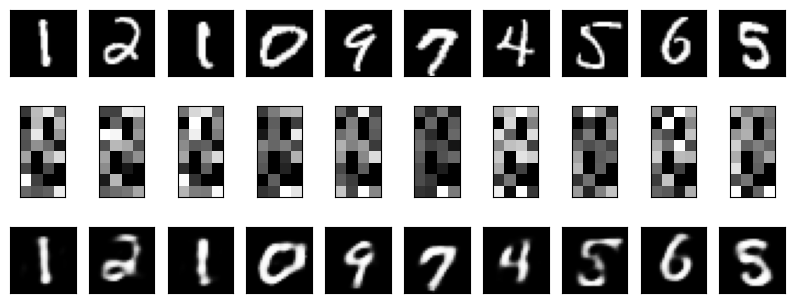

In [38]:
# 1. Configurando a "tela" do gráfico:
# nrows=3: Cria 3 linhas (1ª Original, 2ª Codificada, 3ª Reconstruída).
# ncols=numero_imagens: Cria 10 colunas (uma para cada imagem de teste).
# figsize=(10, 4): Define o tamanho da janela de visualização.
fig, axes = plt.subplots(nrows=3, ncols=numero_imagens, figsize=(10, 4))
#nrows=3 linhas, número de imagens 10 e tamanho da figura
#imagens do teste (original), imagem codificada, e imagem decodificada, tem que percorrer as imagens ao mesmo tempo;

# 2. O Loop Principal (Linhas):
# O zip agrupa os 3 blocos de dados com as 3 linhas do gráfico (axes).
# Na primeira volta, 'imagens' será o bloco de originais e 'ax_row' será a linha 0.
for imagens, ax_row in zip([imagens_teste, imagens_codificadas, imagens_decodificadas], axes):
    
  # 3. O Loop Secundário (Colunas):
  # Percorre cada imagem individual dentro daquela linha.    
  for img, ax in zip(imagens, ax_row):
    # Desenha a imagem no quadradinho (ax) atual em tons de cinza
    # Remove os números dos eixos X e Y (réguas) para deixar o visual limpo,
    # focando apenas na imagem e não nas coordenadas.      
    ax.imshow(img, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [40]:
# imagem teste
# imagem codificada
# imagem decodificada

# autoenconder simples, com uma camada simples apenas, cinza

In [41]:
# 4 pixels de laguras (x), e 8 pixels de largura (y) => diminuir o armazenamento